<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/9_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import AffinityPropagation
from sklearn.datasets import make_blobs

In [21]:
centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=300, centers=centers, cluster_std=0.5, random_state=0
)

In [22]:
af = AffinityPropagation(preference=-50, random_state=0).fit(X)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_

n_clusters_ = len(cluster_centers_indices)

print("Estimated number of clusters: %d" % n_clusters_)
print("Homogeneity: %0.3f" % metrics.homogeneity_score(labels_true, labels))
print("Completeness: %0.3f" % metrics.completeness_score(labels_true, labels))
print("V-measure: %0.3f" % metrics.v_measure_score(labels_true, labels))
print("Adjusted Rand Index: %0.3f" % metrics.adjusted_rand_score(labels_true, labels))

print(
    "Adjusted Mutual Information: %0.3f"
    % metrics.adjusted_mutual_info_score(labels_true, labels)
)

print(
    "Silhouette Coefficient: %0.3f"
    % metrics.silhouette_score(X, labels, metric="sqeuclidean")
)

Estimated number of clusters: 3
Homogeneity: 0.872
Completeness: 0.872
V-measure: 0.872
Adjusted Rand Index: 0.912
Adjusted Mutual Information: 0.871
Silhouette Coefficient: 0.753


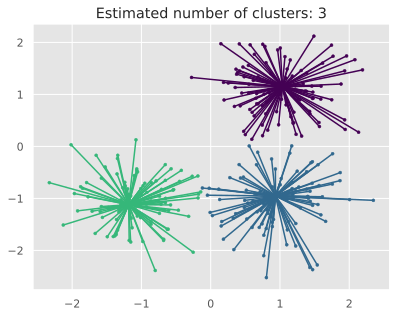

In [23]:
import matplotlib.pyplot as plt

plt.close("all")
plt.figure(1)
plt.clf()

colors = plt.cycler("color", plt.cm.viridis(np.linspace(0, 1, 4)))

for k, col in zip(range(n_clusters_), colors):
    class_members = labels == k
    cluster_center = X[cluster_centers_indices[k]]

    plt.scatter(
        X[class_members, 0], X[class_members, 1], color=col["color"], marker="."
    )

    plt.scatter(
        cluster_center[0], cluster_center[1], s=14, color=col["color"], marker="o"
    )

    for x in X[class_members]:
        plt.plot(
            [cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"]
        )

plt.title("Estimated number of clusters: %d" % n_clusters_)
plt.show()

/tmp/ipykernel_679/245957230.py:4: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf')
/tmp/ipykernel_679/245957230.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], alpha=0.7, edgecolors='b', cmap=plt.cm.RdYlGn)


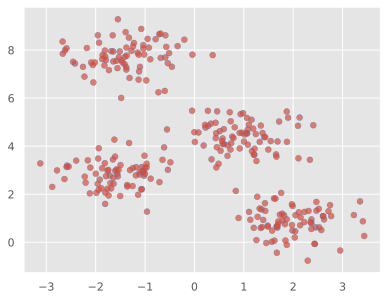

In [24]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf')

import seaborn as sns
sns.set()
plt.style.use('ggplot')

from sklearn.datasets import make_blobs
from sklearn.cluster import AffinityPropagation

X, clusters =make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, edgecolors='b', cmap=plt.cm.RdYlGn)

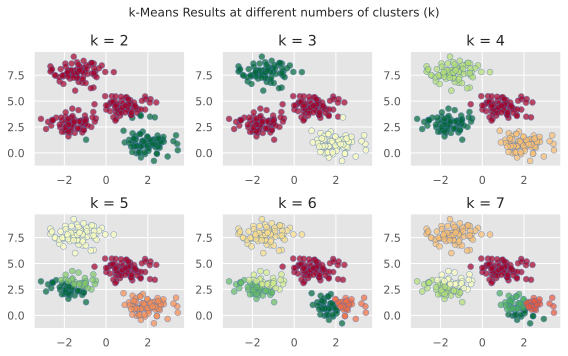

In [25]:
from sklearn.cluster import KMeans

kmeans_results = []
for k in range(2, 8):
    kmeans_results.append(KMeans(n_clusters=k, random_state=0).fit(X))

fig, axs = plt.subplots(2, 3, figsize=(8, 5))
axs = axs.flatten()

for i, k in enumerate(range(2, 8)):
    ax = axs[i]
    kmeans = kmeans_results[i]
    ax.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, alpha=0.7, edgecolors='b', cmap=plt.cm.RdYlGn)
    ax.set_title('k = {}'.format(k))

plt.suptitle('k-Means Results at different numbers of clusters (k)')
fig.tight_layout()
plt.show()

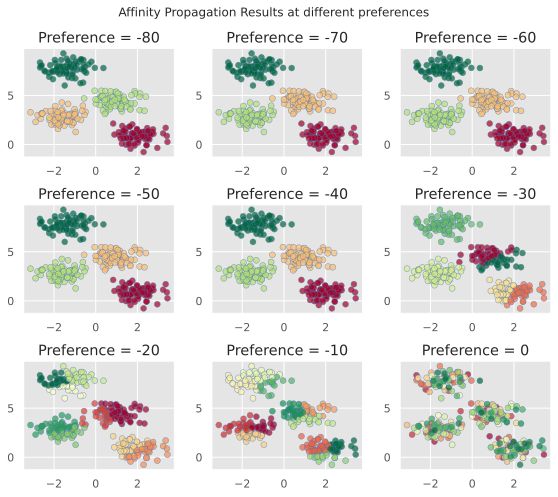

In [26]:
af_results = []

for pref in range(-80, 1, 10):
    af_results.append(AffinityPropagation(preference=pref, random_state=0).fit(X))

fig, axs = plt.subplots(3, 3, figsize=(8, 7))
axs = axs.flatten()

for i, pref in enumerate(range(-80, 1, 10)):
    af_clustering = af_results[i]
    ax = axs[i]
    ax.scatter(X[:, 0], X[:, 1], c=af_clustering.labels_, alpha=0.7, edgecolors='b', cmap=plt.cm.RdYlGn)

    ax.set_title('Preference = {}'.format(pref))

plt.suptitle('Affinity Propagation Results at different preferences')
plt.tight_layout()

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

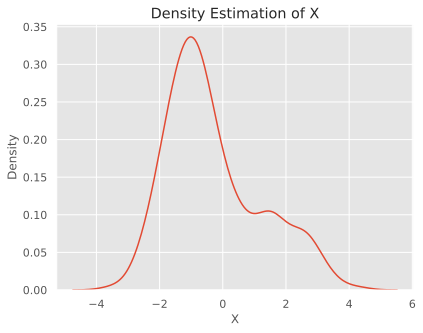

In [28]:
mu1, sigma1 = 2,1
mu2, sigma2 = -1, 0.8
X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

In [29]:
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1)/len(X), len(X2)/len(X)

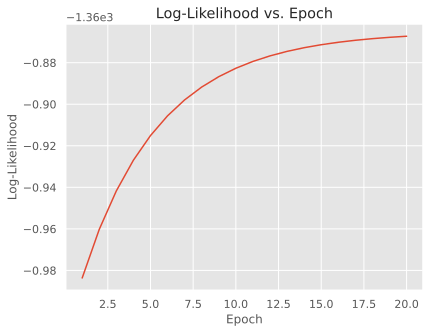

In [32]:
# Perform EM algorithm for 20 epochs
num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    # E-step: Compute responsibilities
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)

    total = gamma1 + gamma2

    gamma1 /= total
    gamma2 /= total

    # M-step: Update parameters
    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat) ** 2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat) ** 2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)

    # Compute log-likelihood
    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
            + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)

plt.plot(range(1, num_epochs + 1), log_likelihoods)
plt.xlabel("Epoch")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs. Epoch")
plt.show()

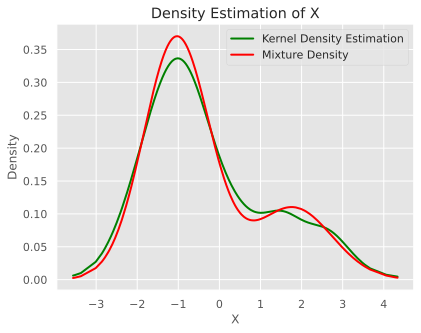

In [33]:
# Plot the final estimated density
from scipy.stats import gaussian_kde
X_sorted = np.sort(X)
density_estimation = pi1_hat*norm.pdf(X_sorted, mu1_hat, sigma1_hat) + pi2_hat*norm.pdf(X_sorted, mu2_hat, sigma2_hat)

plt.plot(X_sorted, gaussian_kde(X_sorted)(X_sorted), color="green", linewidth=2)
plt.plot(X_sorted, density_estimation, color="red", linewidth=2 )
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Density Estimation of X")
plt.legend(["Kernel Density Estimation", "Mixture Density"])
plt.show()